# FreightRisk V2: Constraint-Aware Freight Risk Decision Support

**Project goal:** Build a freight-risk scoring system that identifies orders likely to have freight feasibility issues before shipment planning.

This V2 notebook is the clean final version of the capstone workflow. It summarizes the EDA, model comparison, ensemble modeling, final model selection, and business use case using the final exported V2 outputs.

## 1. Project Overview

FreightRisk reframes a single-day supply chain logistics dataset into a freight execution risk problem.

The core modeling target is:

- **1 = freight infeasible / high-risk**
- **0 = freight feasible**

The model predicts the probability that an order will not have valid freight coverage and converts that probability into planner-friendly risk bands.

In [27]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

FINAL_V2_FOLDER = Path("finalv2_outputs")
TABLE_FOLDER = FINAL_V2_FOLDER / "tables"
FIGURE_FOLDER = FINAL_V2_FOLDER / "figures"
MODEL_FOLDER = FINAL_V2_FOLDER / "models"

print("Final V2 folder:", FINAL_V2_FOLDER.resolve())
print("Tables found:", len(list(TABLE_FOLDER.glob("*.csv"))))
print("Figures found:", len(list(FIGURE_FOLDER.glob("*.png"))))

Final V2 folder: C:\Users\HayesTest\OneDrive\Desktop\capstone\finalv2_outputs
Tables found: 21
Figures found: 7


## 2. Load Final V2 Tables

The final tables were exported from the working modeling notebook. This keeps the V2 notebook clean and submission-ready while preserving the final results.

In [28]:
model_comparison_final = pd.read_csv(TABLE_FOLDER / "model_comparison_final.csv")
ensemble_comparison_summary = pd.read_csv(TABLE_FOLDER / "ensemble_comparison_summary.csv")
final_candidate_models = pd.read_csv(TABLE_FOLDER / "final_candidate_models.csv")
risk_band_summary = pd.read_csv(TABLE_FOLDER / "risk_band_summary.csv")
final_test_scored = pd.read_csv(TABLE_FOLDER / "final_test_scored.csv")

display(model_comparison_final.head())
display(ensemble_comparison_summary.head())
display(risk_band_summary)

,model_name,model_family,selected_threshold,cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,false_positive,false_negative,true_positive,true_negative,total_errors
0,Gradient Boosting,Boosting Ensemble,0.40,0.960417,0.980035,0.967033,0.949640,0.958258,0.997753,18,28,528,1730,46
1,Stacking Ensemble,Ensemble,0.35,NaN,0.979601,0.968692,0.946043,0.957234,0.998121,17,30,526,1731,47
2,Random Forest,Tree Ensemble,0.30,0.957312,0.976997,0.937391,0.969424,0.953139,0.997855,36,17,539,1712,53
3,Extra Trees,Tree Ensemble,0.40,0.952324,0.970920,0.940541,0.938849,0.939694,0.995216,33,34,522,1715,67
4,Decision Tree,Tree,0.55,0.949141,0.970052,0.941924,0.933453,0.937669,0.984257,32,37,519,1716,69


,model_name,ensemble_type,base_models,selected_threshold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,false_positive,false_negative,true_positive,true_negative,total_errors
0,Stacking Ensemble,Stacking,Gradient Boosting + Random Forest,0.35,0.979601,0.968692,0.946043,0.957234,0.998121,17,30,526,1731,47
1,Validation-Tuned Weighted Ensemble,Weighted Soft Voting,Gradient Boosting + Random Forest,0.50,0.976562,0.980843,0.920863,0.949907,0.998082,10,44,512,1738,54
2,Equal Soft Voting Ensemble,Soft Voting,Gradient Boosting + Random Forest + Logistic R...,0.30,0.973958,0.944444,0.947842,0.946140,0.994888,31,29,527,1717,60


,risk_band,order_count,avg_risk_probability,actual_infeasible_rate,predicted_infeasible_count,order_percent
0,Low,1725,0.012633,0.010435,0,74.869792
1,Medium,49,0.374468,0.387755,16,2.126736
2,High,26,0.608073,0.653846,26,1.128472
3,Critical,504,0.984789,0.996032,504,21.875000


## 3. EDA Summary and Problem Framing

The original dataset looked like it could support a general supply chain prediction problem. However, EDA showed that the order data is a single-day snapshot, so time-series forecasting was not the correct framing.

The project was reframed as a **freight infeasibility classification problem**.

Key EDA findings:

- 9,215 orders were analyzed.
- 2,224 orders were freight-infeasible.
- The infeasible rate was 24.13%.
- Two known freight coverage issues explained almost all infeasible orders.
- PLANT03 was the main capacity bottleneck.
- Rerouting required product, port, freight, and customer-rule constraints.

## 4. Model Comparison

I tested baselines, interpretable models, tree models, ensemble models, distance-based models, and margin-based models.

The main metric is **F1 score for the infeasible freight class**, because the business goal is to catch high-risk freight orders while avoiding too many false alarms.

In [29]:
model_comparison_display = model_comparison_final.sort_values("test_f1", ascending=False)

display(model_comparison_display)

,model_name,model_family,selected_threshold,cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,false_positive,false_negative,true_positive,true_negative,total_errors
0,Gradient Boosting,Boosting Ensemble,0.40,0.960417,0.980035,0.967033,0.949640,0.958258,0.997753,18,28,528,1730,46
1,Stacking Ensemble,Ensemble,0.35,NaN,0.979601,0.968692,0.946043,0.957234,0.998121,17,30,526,1731,47
2,Random Forest,Tree Ensemble,0.30,0.957312,0.976997,0.937391,0.969424,0.953139,0.997855,36,17,539,1712,53
3,Extra Trees,Tree Ensemble,0.40,0.952324,0.970920,0.940541,0.938849,0.939694,0.995216,33,34,522,1715,67
4,Decision Tree,Tree,0.55,0.949141,0.970052,0.941924,0.933453,0.937669,0.984257,32,37,519,1716,69
5,KNN,Distance-Based,0.35,0.937999,0.967448,0.927176,0.938849,0.932976,0.983625,41,34,522,1707,75
6,SVM,Margin-Based,0.60,0.932518,0.964844,0.981744,0.870504,0.922784,0.988219,9,72,484,1739,81
7,Logistic Regression,Linear,0.35,0.727237,0.870660,0.718644,0.762590,0.739965,0.836108,166,132,424,1582,298
8,Stratified Random Baseline,Baseline,NaN,NaN,0.632812,0.241993,0.244604,0.243292,0.500449,426,420,136,1322,846
9,Majority-Class Baseline,Baseline,NaN,NaN,0.758681,0.000000,0.000000,0.000000,0.500000,0,556,0,1748,556


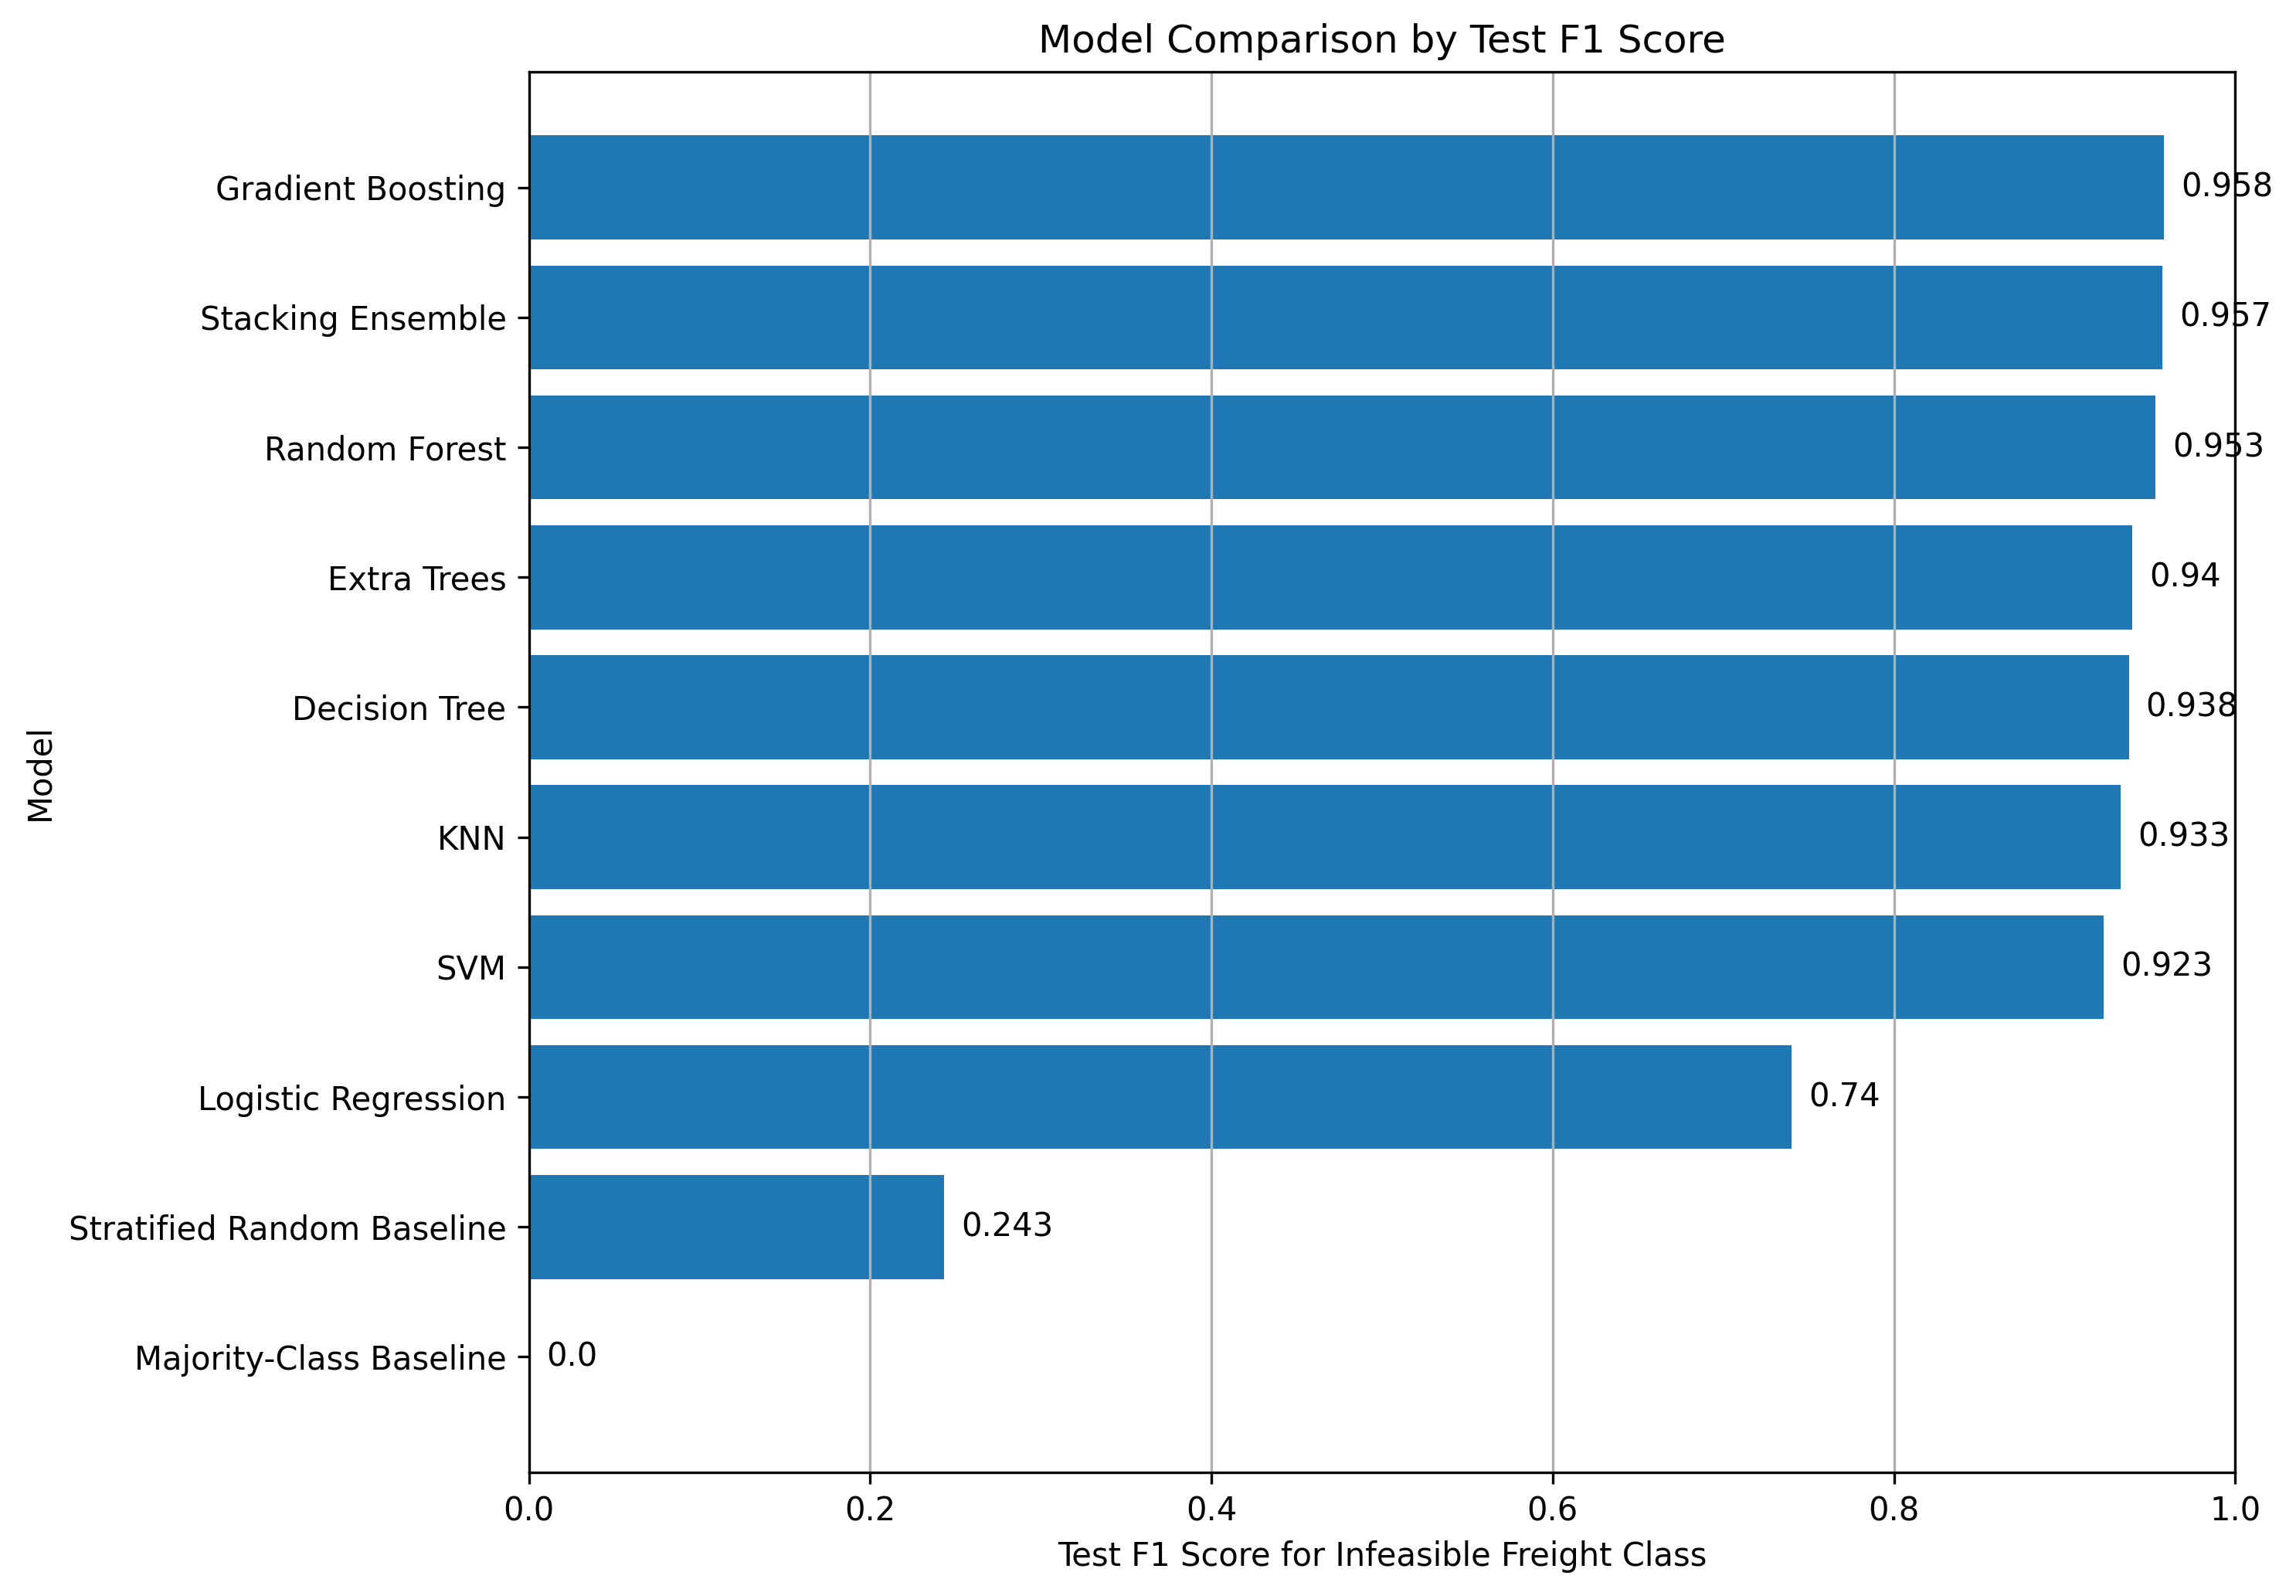

In [30]:
fig_path = FIGURE_FOLDER / "01_model_comparison_test_f1.png"

if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    plot_df = model_comparison_final.sort_values("test_f1", ascending=True)

    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["model_name"], plot_df["test_f1"])
    plt.title("Model Comparison by Test F1 Score")
    plt.xlabel("Test F1 Score")
    plt.ylabel("Model")
    plt.xlim(0, 1)

    for index, value in enumerate(plot_df["test_f1"]):
        plt.text(value + 0.01, index, round(value, 3), va="center")

    plt.grid(axis="x")
    plt.show()

## 5. Precision, Recall, and Error Tradeoffs

Freight-risk modeling needs both precision and recall.

- **False positives** mean a feasible order is unnecessarily reviewed.
- **False negatives** mean an infeasible order is missed.

False negatives are especially important because they represent freight failures that the system did not catch.

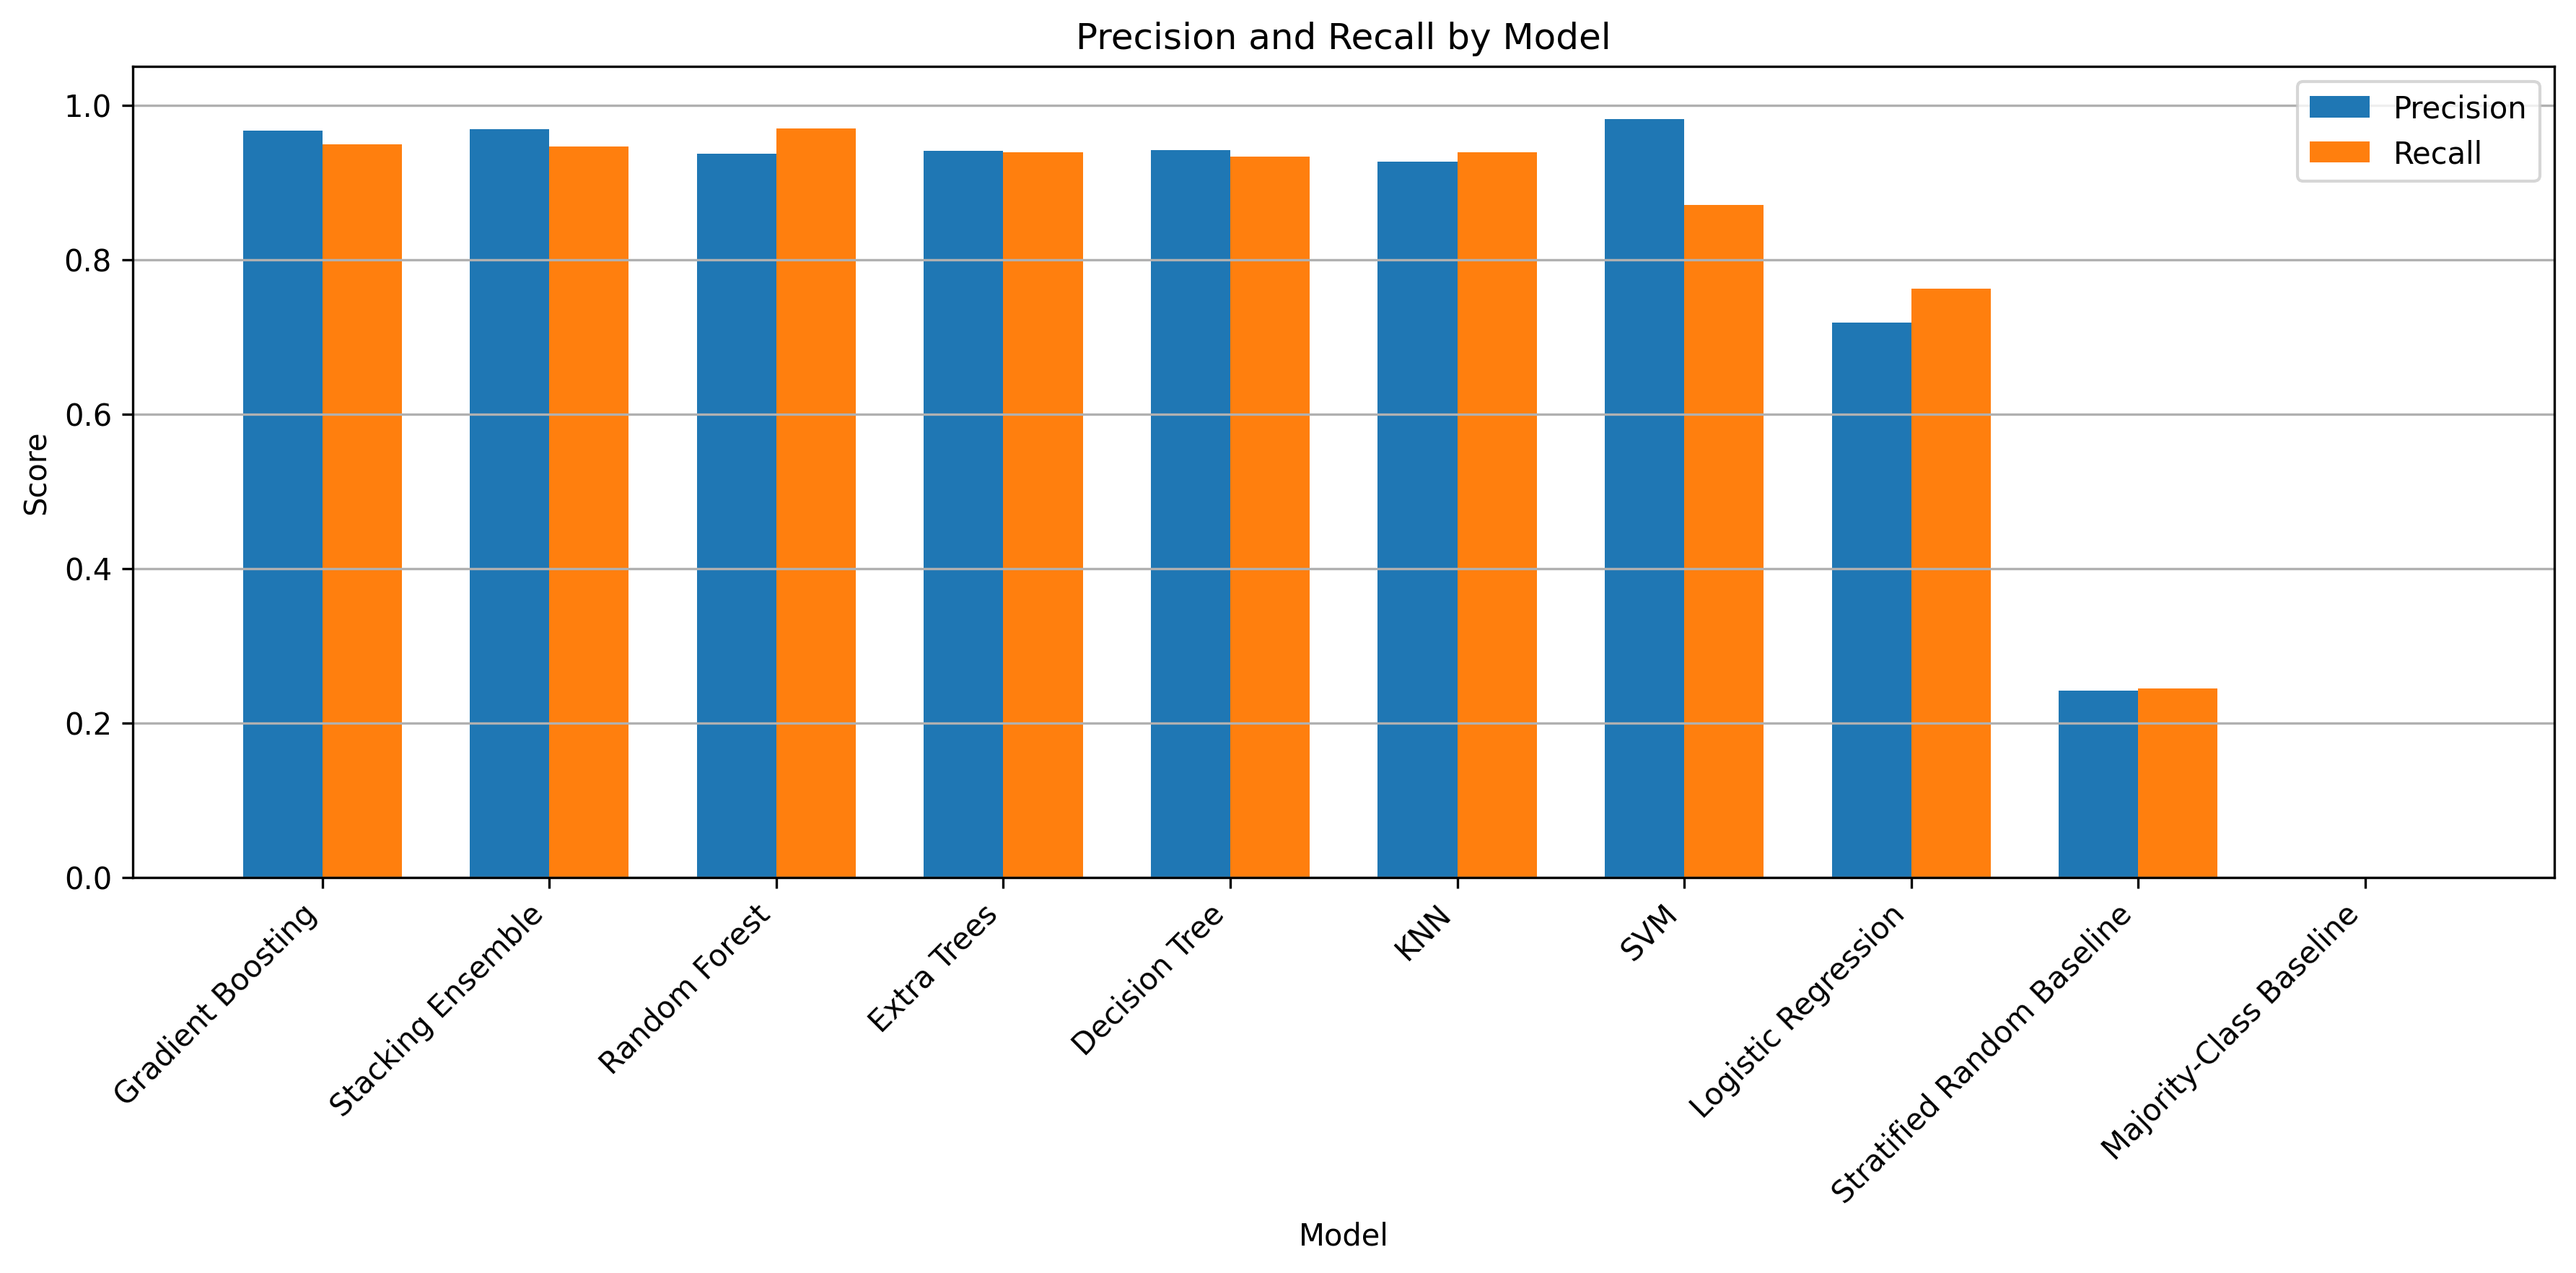

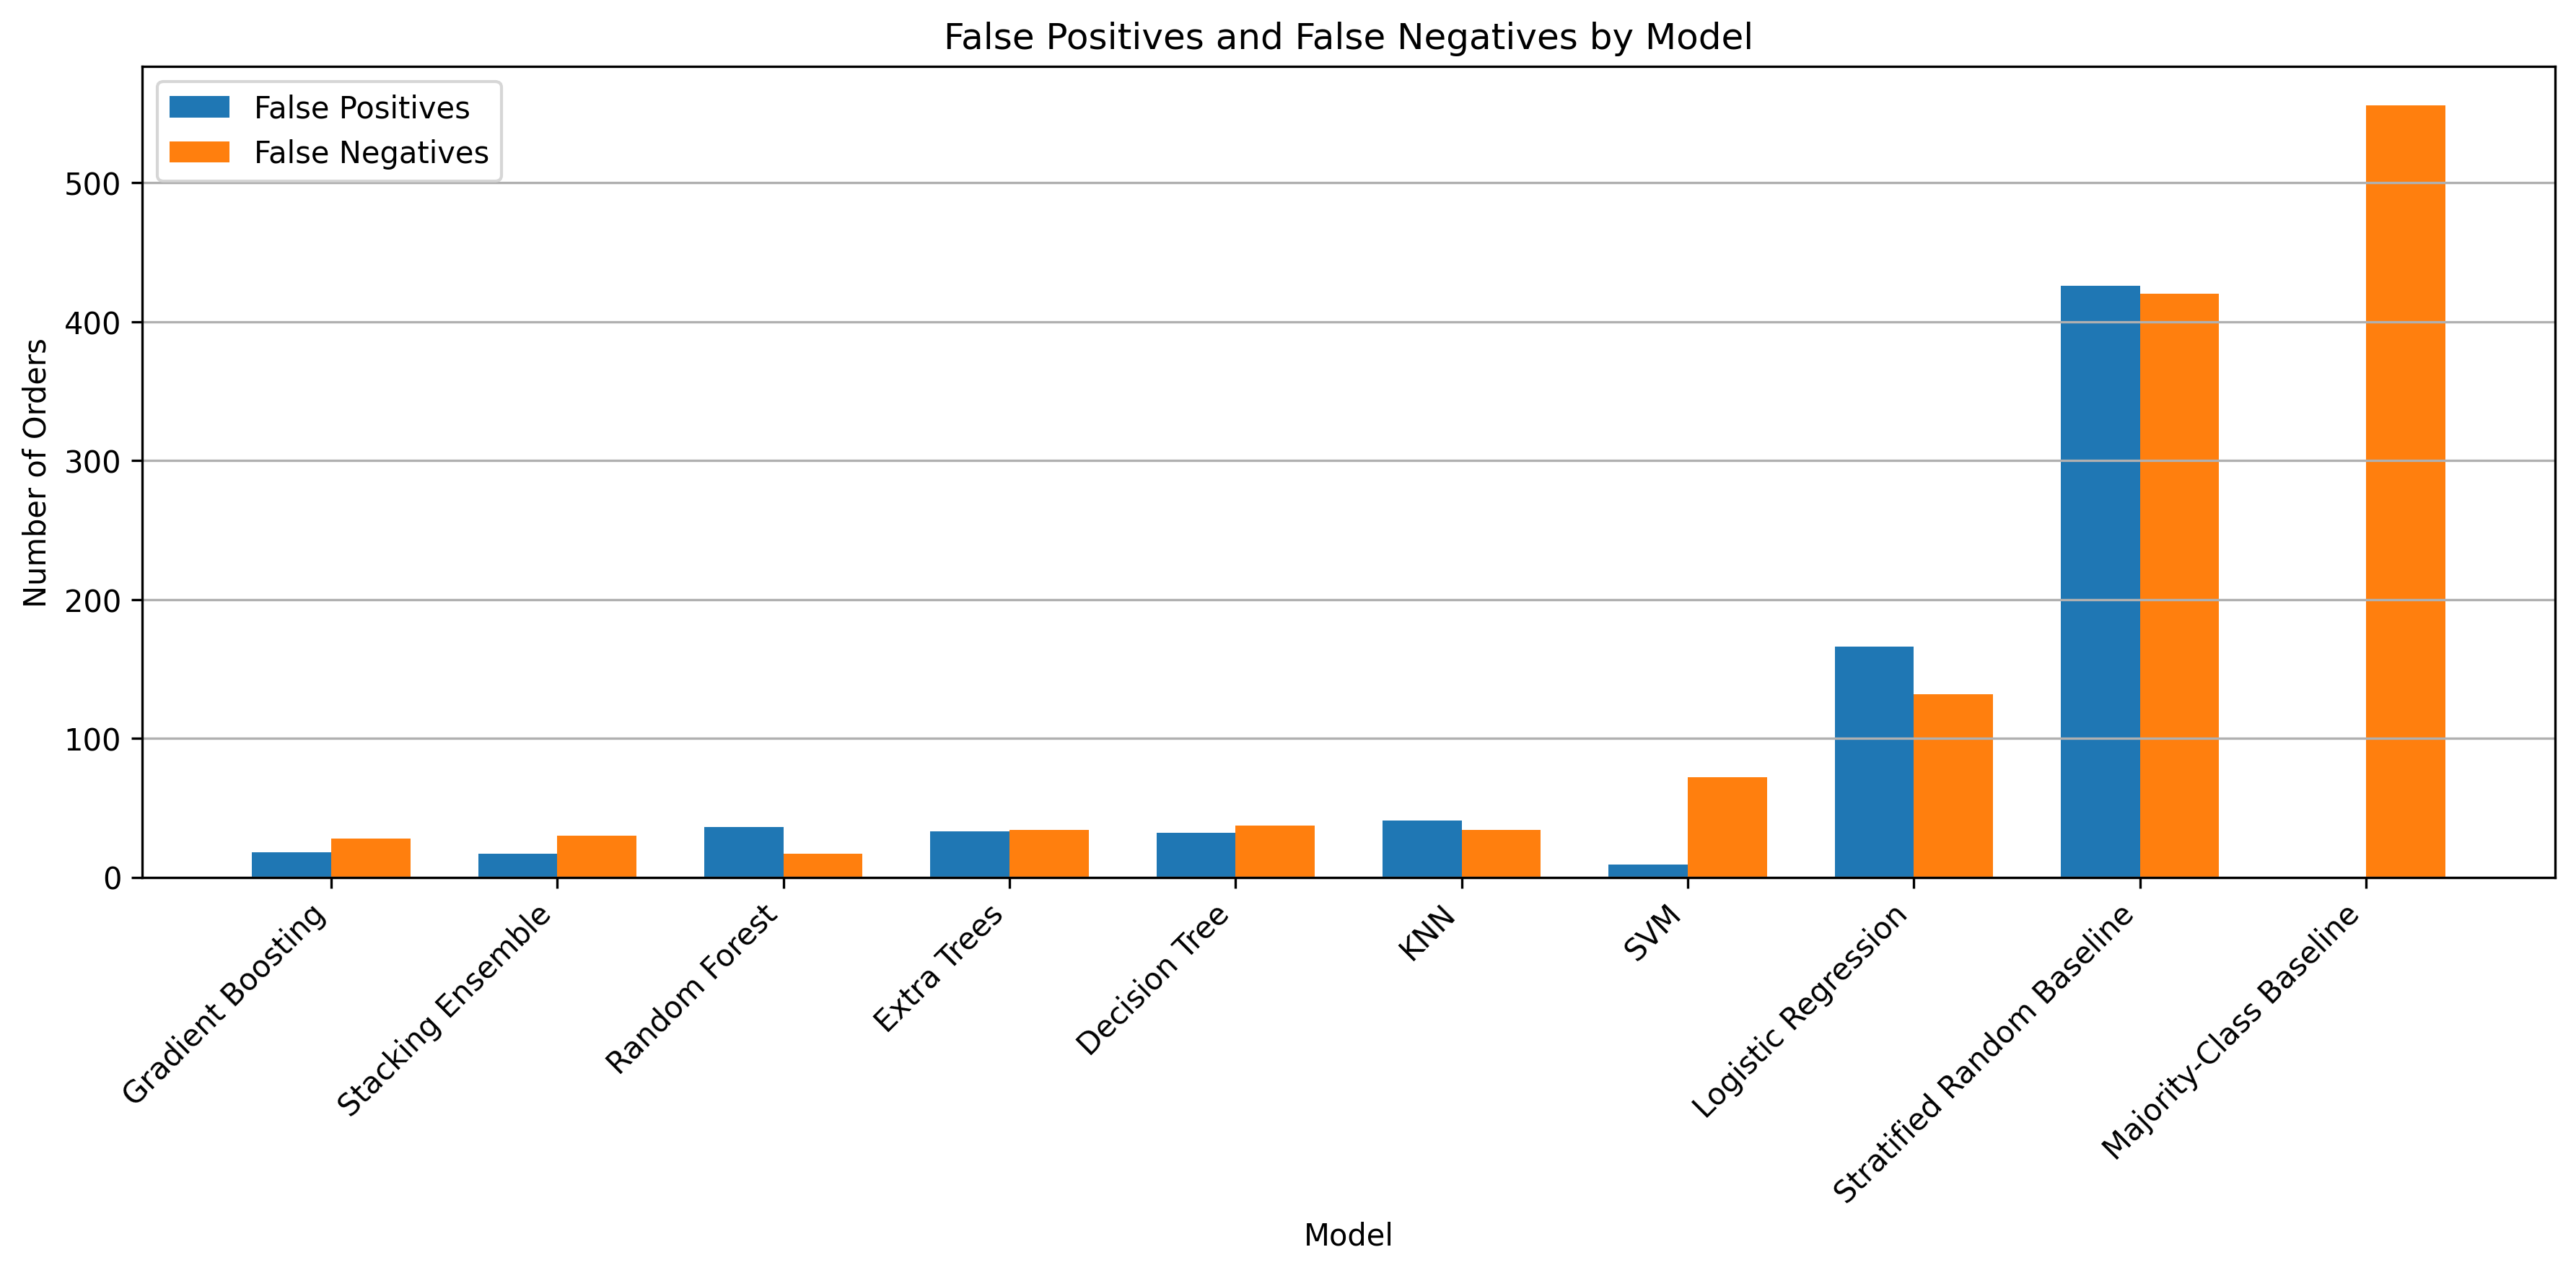

In [31]:
for fig_name in [
    "02_precision_recall_by_model.png",
    "03_false_positive_false_negative_by_model.png"
]:
    fig_path = FIGURE_FOLDER / fig_name

    if fig_path.exists():
        display(Image(filename=str(fig_path)))
    else:
        print("Figure not found:", fig_path)

## 6. Ensemble Modeling

The project requirement asks for promising models to be combined into an ensemble.

I tested three ensemble approaches:

1. Equal soft voting
2. Validation-tuned weighted soft voting
3. Stacking ensemble

Stacking was the strongest ensemble model.

In [32]:
ensemble_comparison_display = ensemble_comparison_summary.sort_values("test_f1", ascending=False)

display(ensemble_comparison_display)

,model_name,ensemble_type,base_models,selected_threshold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,false_positive,false_negative,true_positive,true_negative,total_errors
0,Stacking Ensemble,Stacking,Gradient Boosting + Random Forest,0.35,0.979601,0.968692,0.946043,0.957234,0.998121,17,30,526,1731,47
1,Validation-Tuned Weighted Ensemble,Weighted Soft Voting,Gradient Boosting + Random Forest,0.50,0.976562,0.980843,0.920863,0.949907,0.998082,10,44,512,1738,54
2,Equal Soft Voting Ensemble,Soft Voting,Gradient Boosting + Random Forest + Logistic R...,0.30,0.973958,0.944444,0.947842,0.946140,0.994888,31,29,527,1717,60


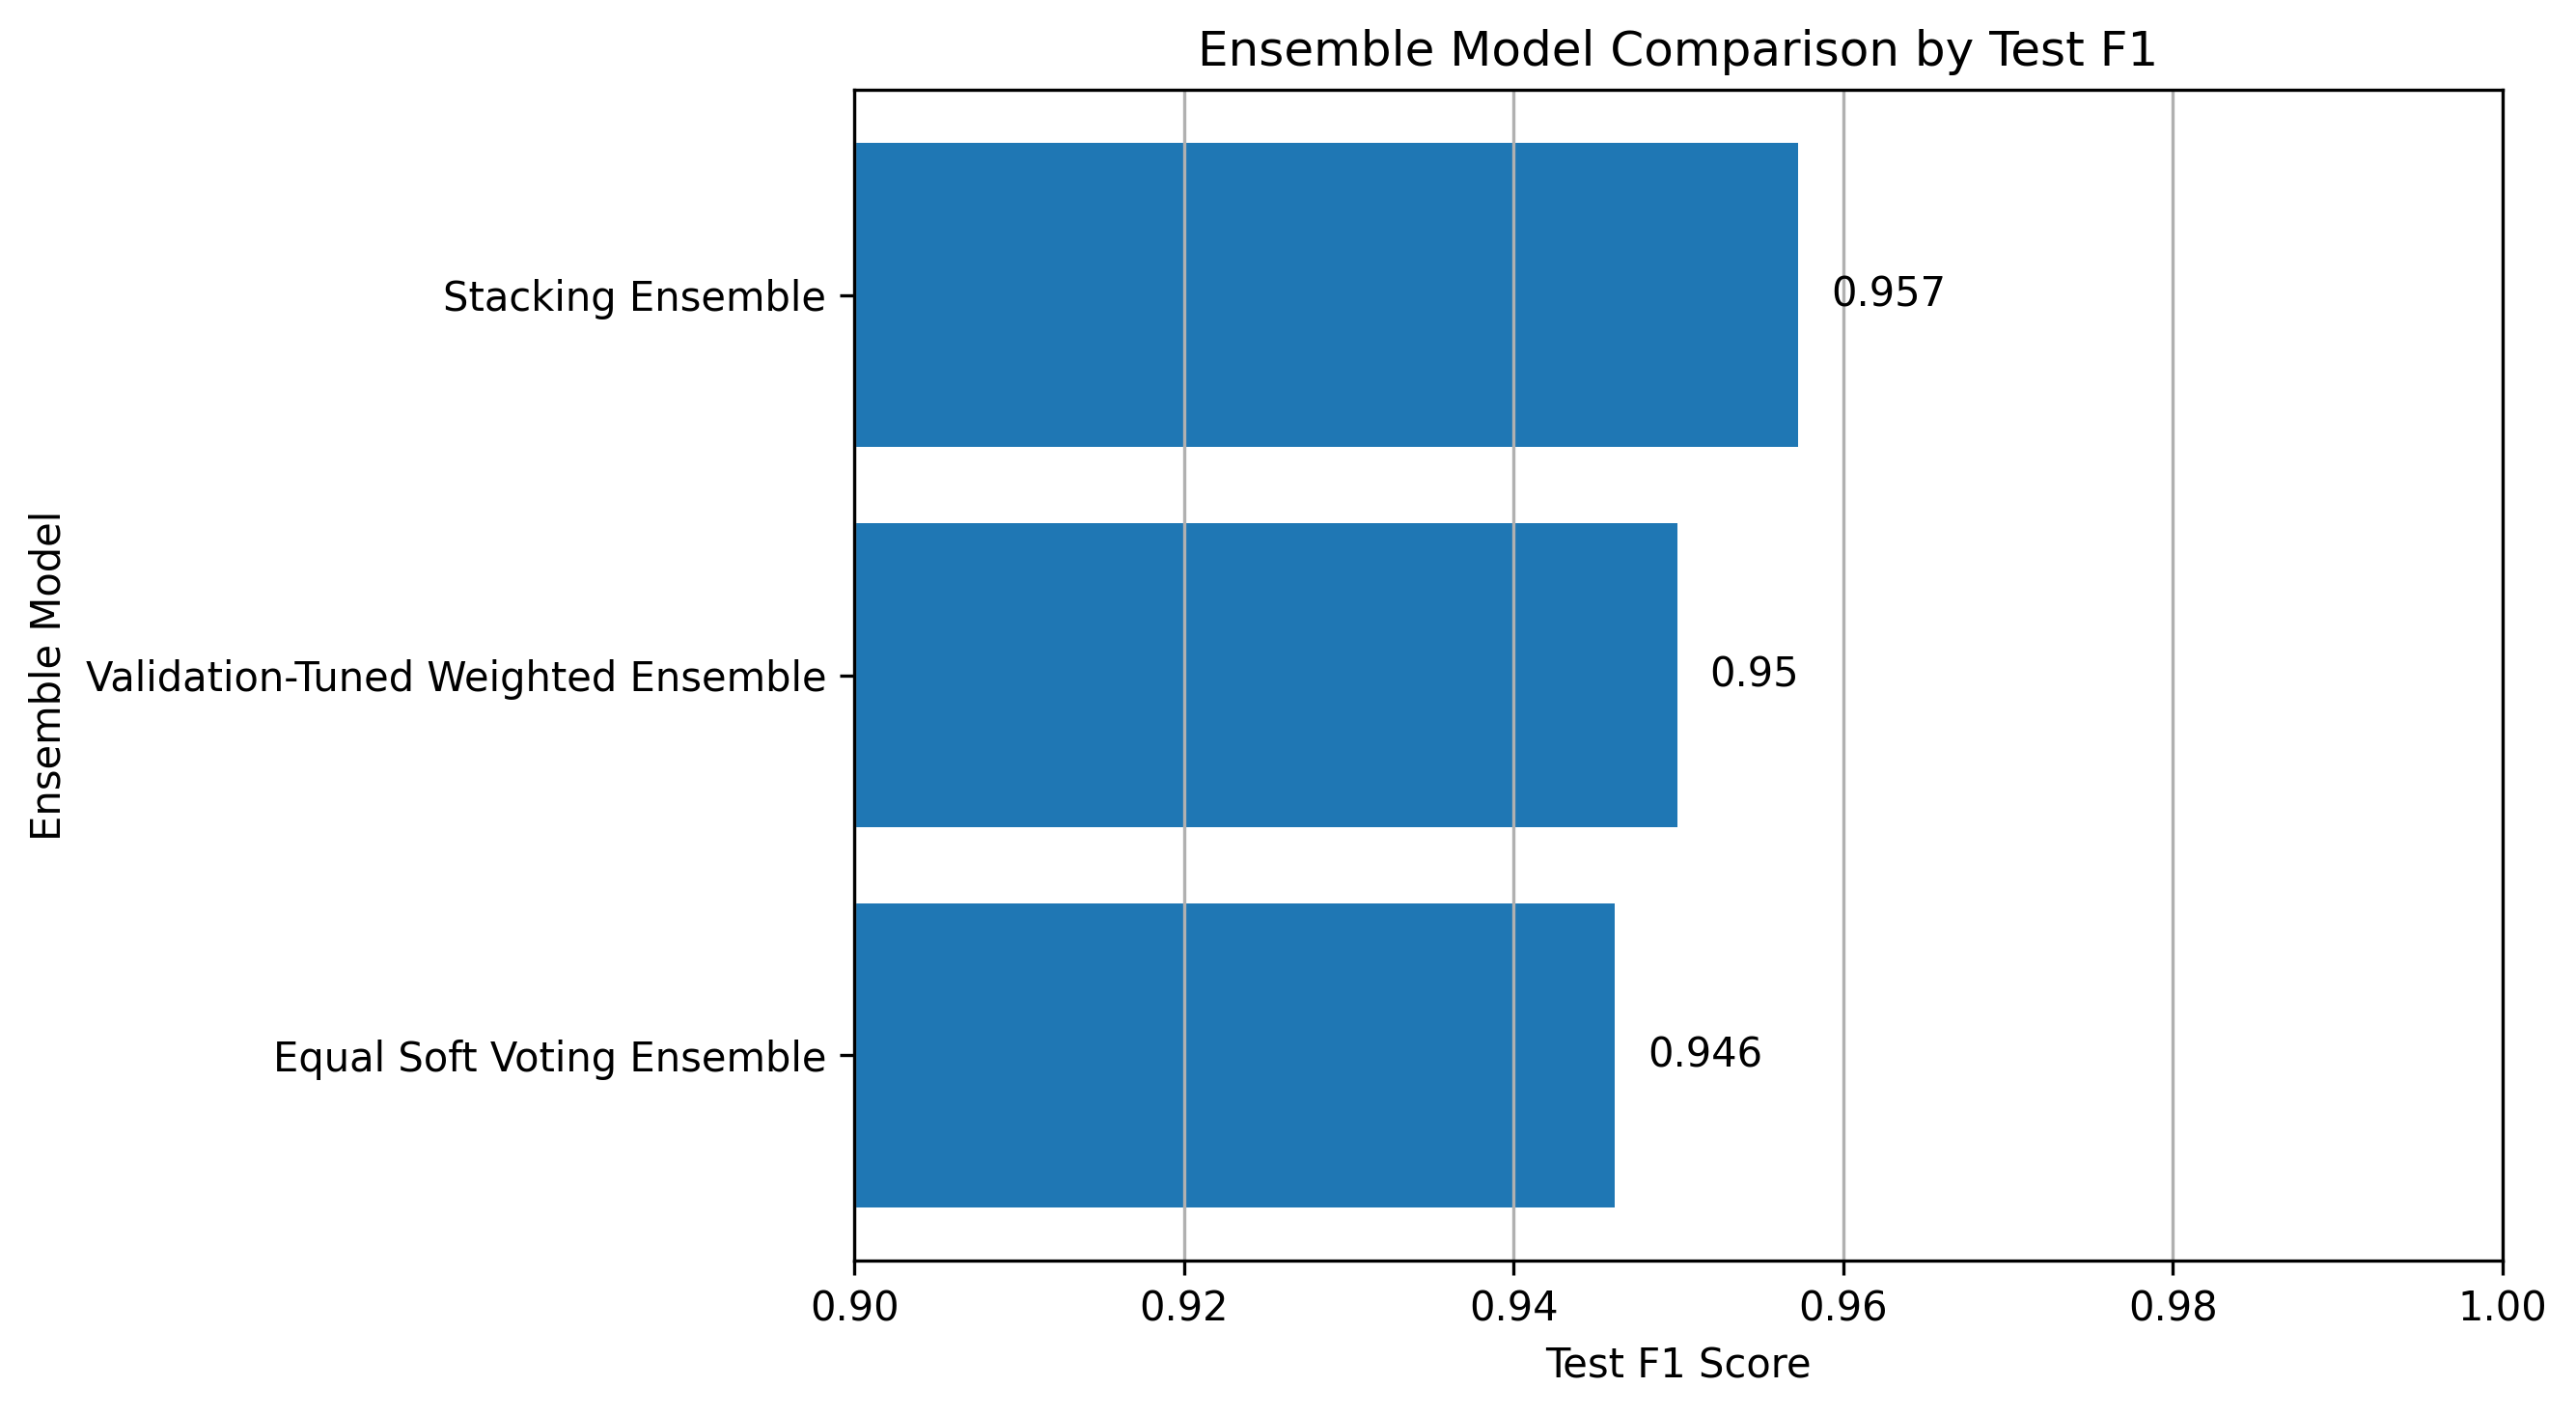

In [33]:
fig_path = FIGURE_FOLDER / "04_ensemble_comparison_test_f1.png"

if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    plot_df = ensemble_comparison_summary.sort_values("test_f1", ascending=True)

    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["model_name"], plot_df["test_f1"])
    plt.title("Ensemble Model Comparison by Test F1")
    plt.xlabel("Test F1 Score")
    plt.ylabel("Ensemble")
    plt.xlim(0.90, 1.00)
    plt.grid(axis="x")
    plt.show()

## 7. Final Model Selection

The final model decision compares the best overall model, best ensemble model, and best high-recall backup model.

Final decision:

- **Primary final model:** Gradient Boosting at threshold 0.40
- **Best ensemble:** Stacking Ensemble at threshold 0.35
- **High-recall backup:** Random Forest at threshold 0.30

In [34]:
display(final_candidate_models)

,model_name,role,selected_threshold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,false_positive,false_negative,total_errors
0,Gradient Boosting,Best overall F1,0.40,0.980035,0.967033,0.949640,0.958258,0.997753,18,28,46
1,Stacking Ensemble,Best ensemble,0.35,0.979601,0.968692,0.946043,0.957234,0.998121,17,30,47
2,Random Forest,Best recall / fewest false negatives,0.30,0.976997,0.937391,0.969424,0.953139,0.997855,36,17,53


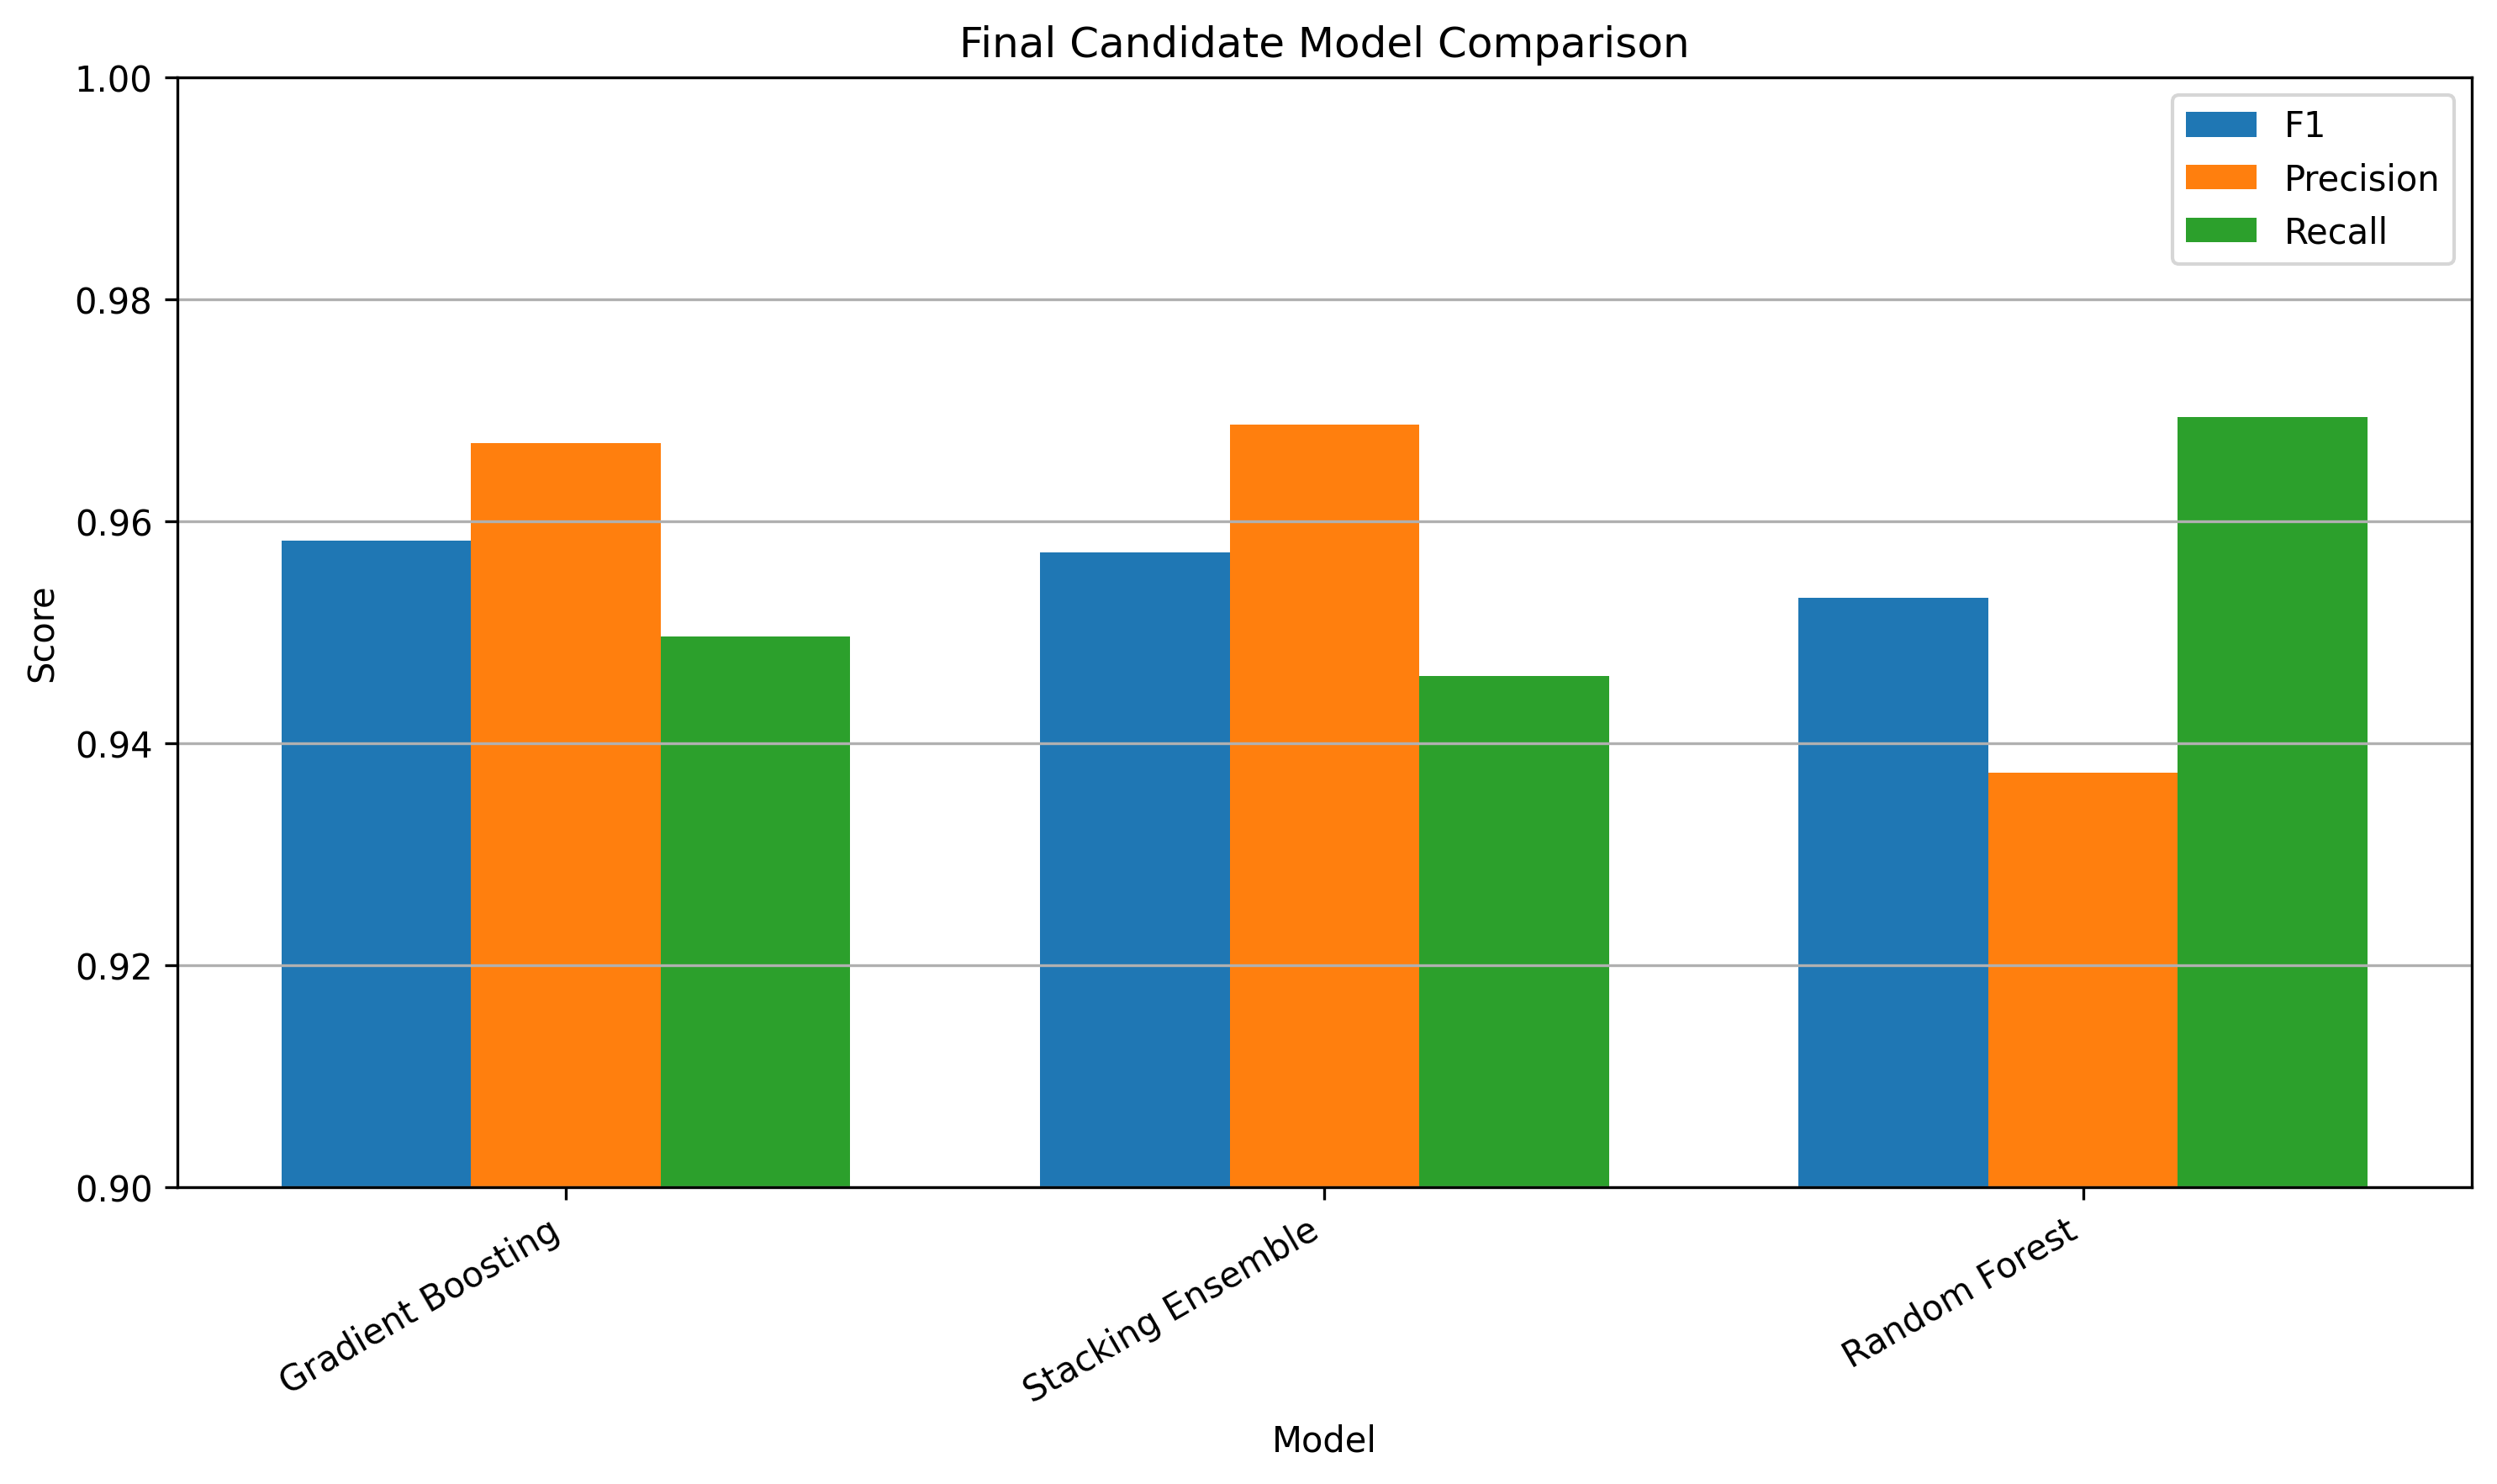

In [35]:
fig_path = FIGURE_FOLDER / "05_final_candidate_model_comparison.png"

if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    candidate_plot_df = final_candidate_models.copy()

    x = np.arange(len(candidate_plot_df))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, candidate_plot_df["test_f1"], width, label="F1")
    plt.bar(x, candidate_plot_df["test_precision"], width, label="Precision")
    plt.bar(x + width, candidate_plot_df["test_recall"], width, label="Recall")

    plt.title("Final Candidate Model Comparison")
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.xticks(x, candidate_plot_df["model_name"], rotation=30, ha="right")
    plt.ylim(0.90, 1.00)
    plt.legend()
    plt.grid(axis="y")
    plt.show()

## 8. Final Selected Model Explanation

Gradient Boosting is selected as the final leading model because it achieved the strongest held-out test F1 score and the lowest total error count among the final candidates.

The stacking ensemble performed almost as well and is the strongest ensemble result. However, it did not improve enough over Gradient Boosting to replace it.

Random Forest is kept as a high-recall backup model because it produced the fewest false negatives.

## 9. Risk Bands and Business Use Case

The final model produces a predicted freight-risk probability. To make this usable for planners, probabilities are converted into four risk bands:

- Low
- Medium
- High
- Critical

These bands turn model scores into an operational review queue.

In [36]:
display(risk_band_summary)

,risk_band,order_count,avg_risk_probability,actual_infeasible_rate,predicted_infeasible_count,order_percent
0,Low,1725,0.012633,0.010435,0,74.869792
1,Medium,49,0.374468,0.387755,16,2.126736
2,High,26,0.608073,0.653846,26,1.128472
3,Critical,504,0.984789,0.996032,504,21.875000


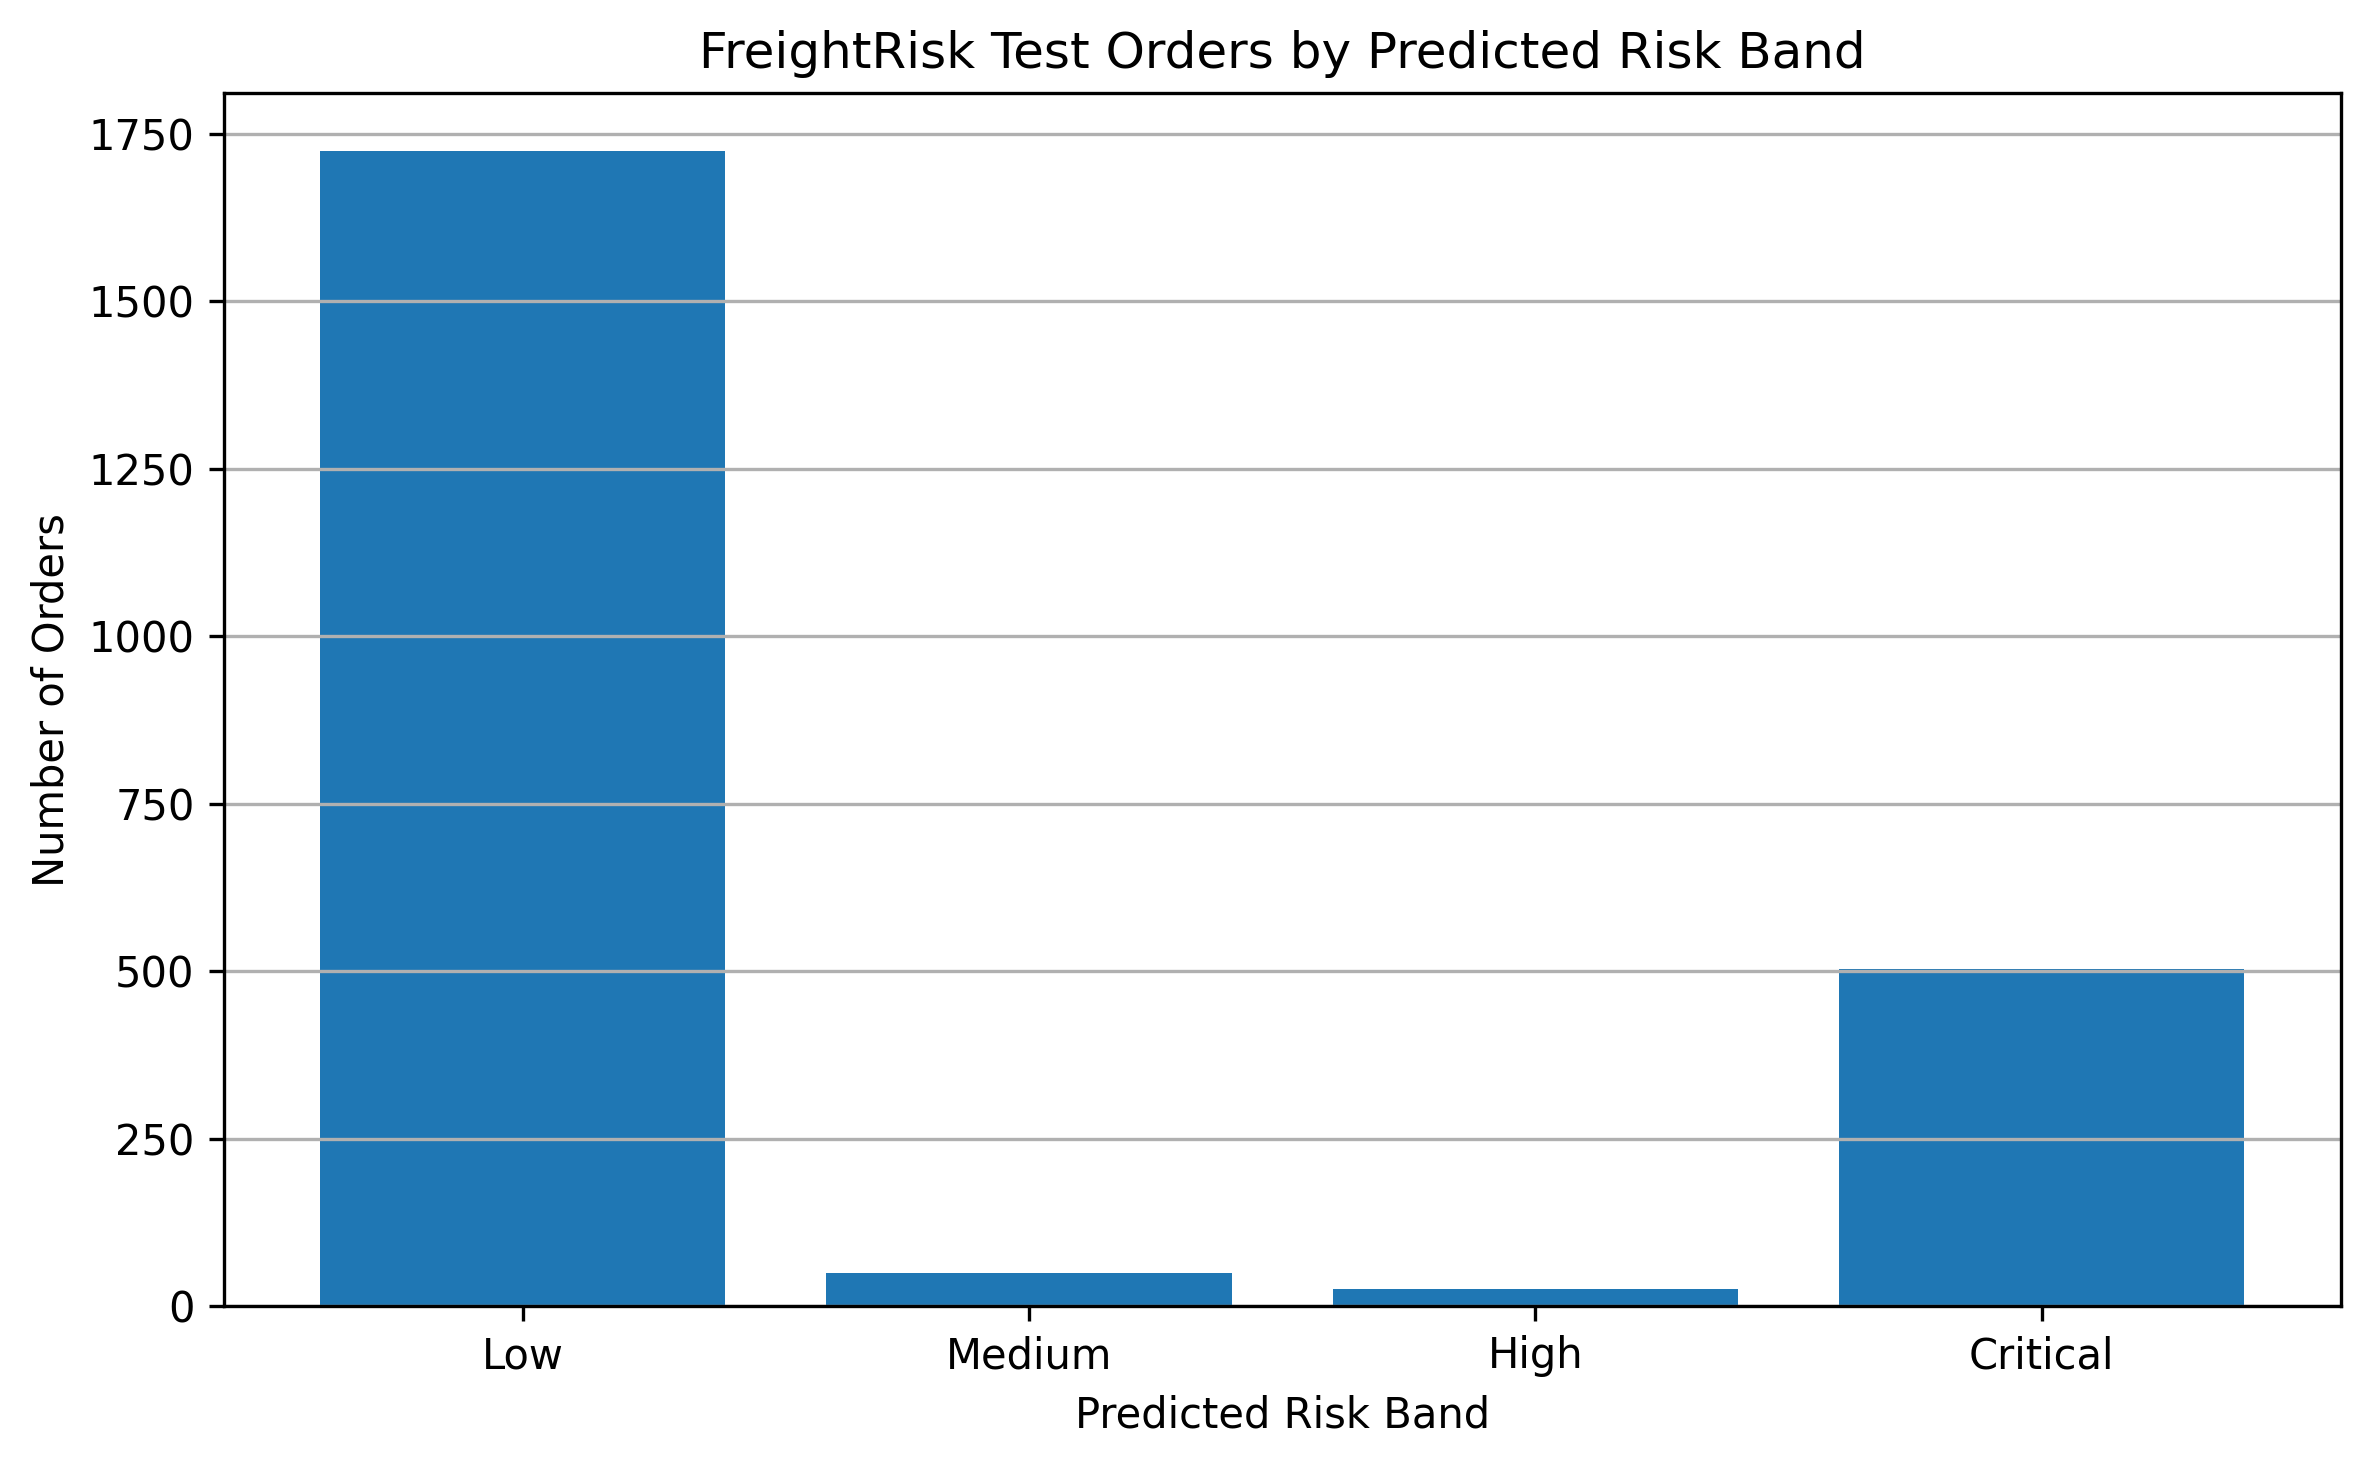

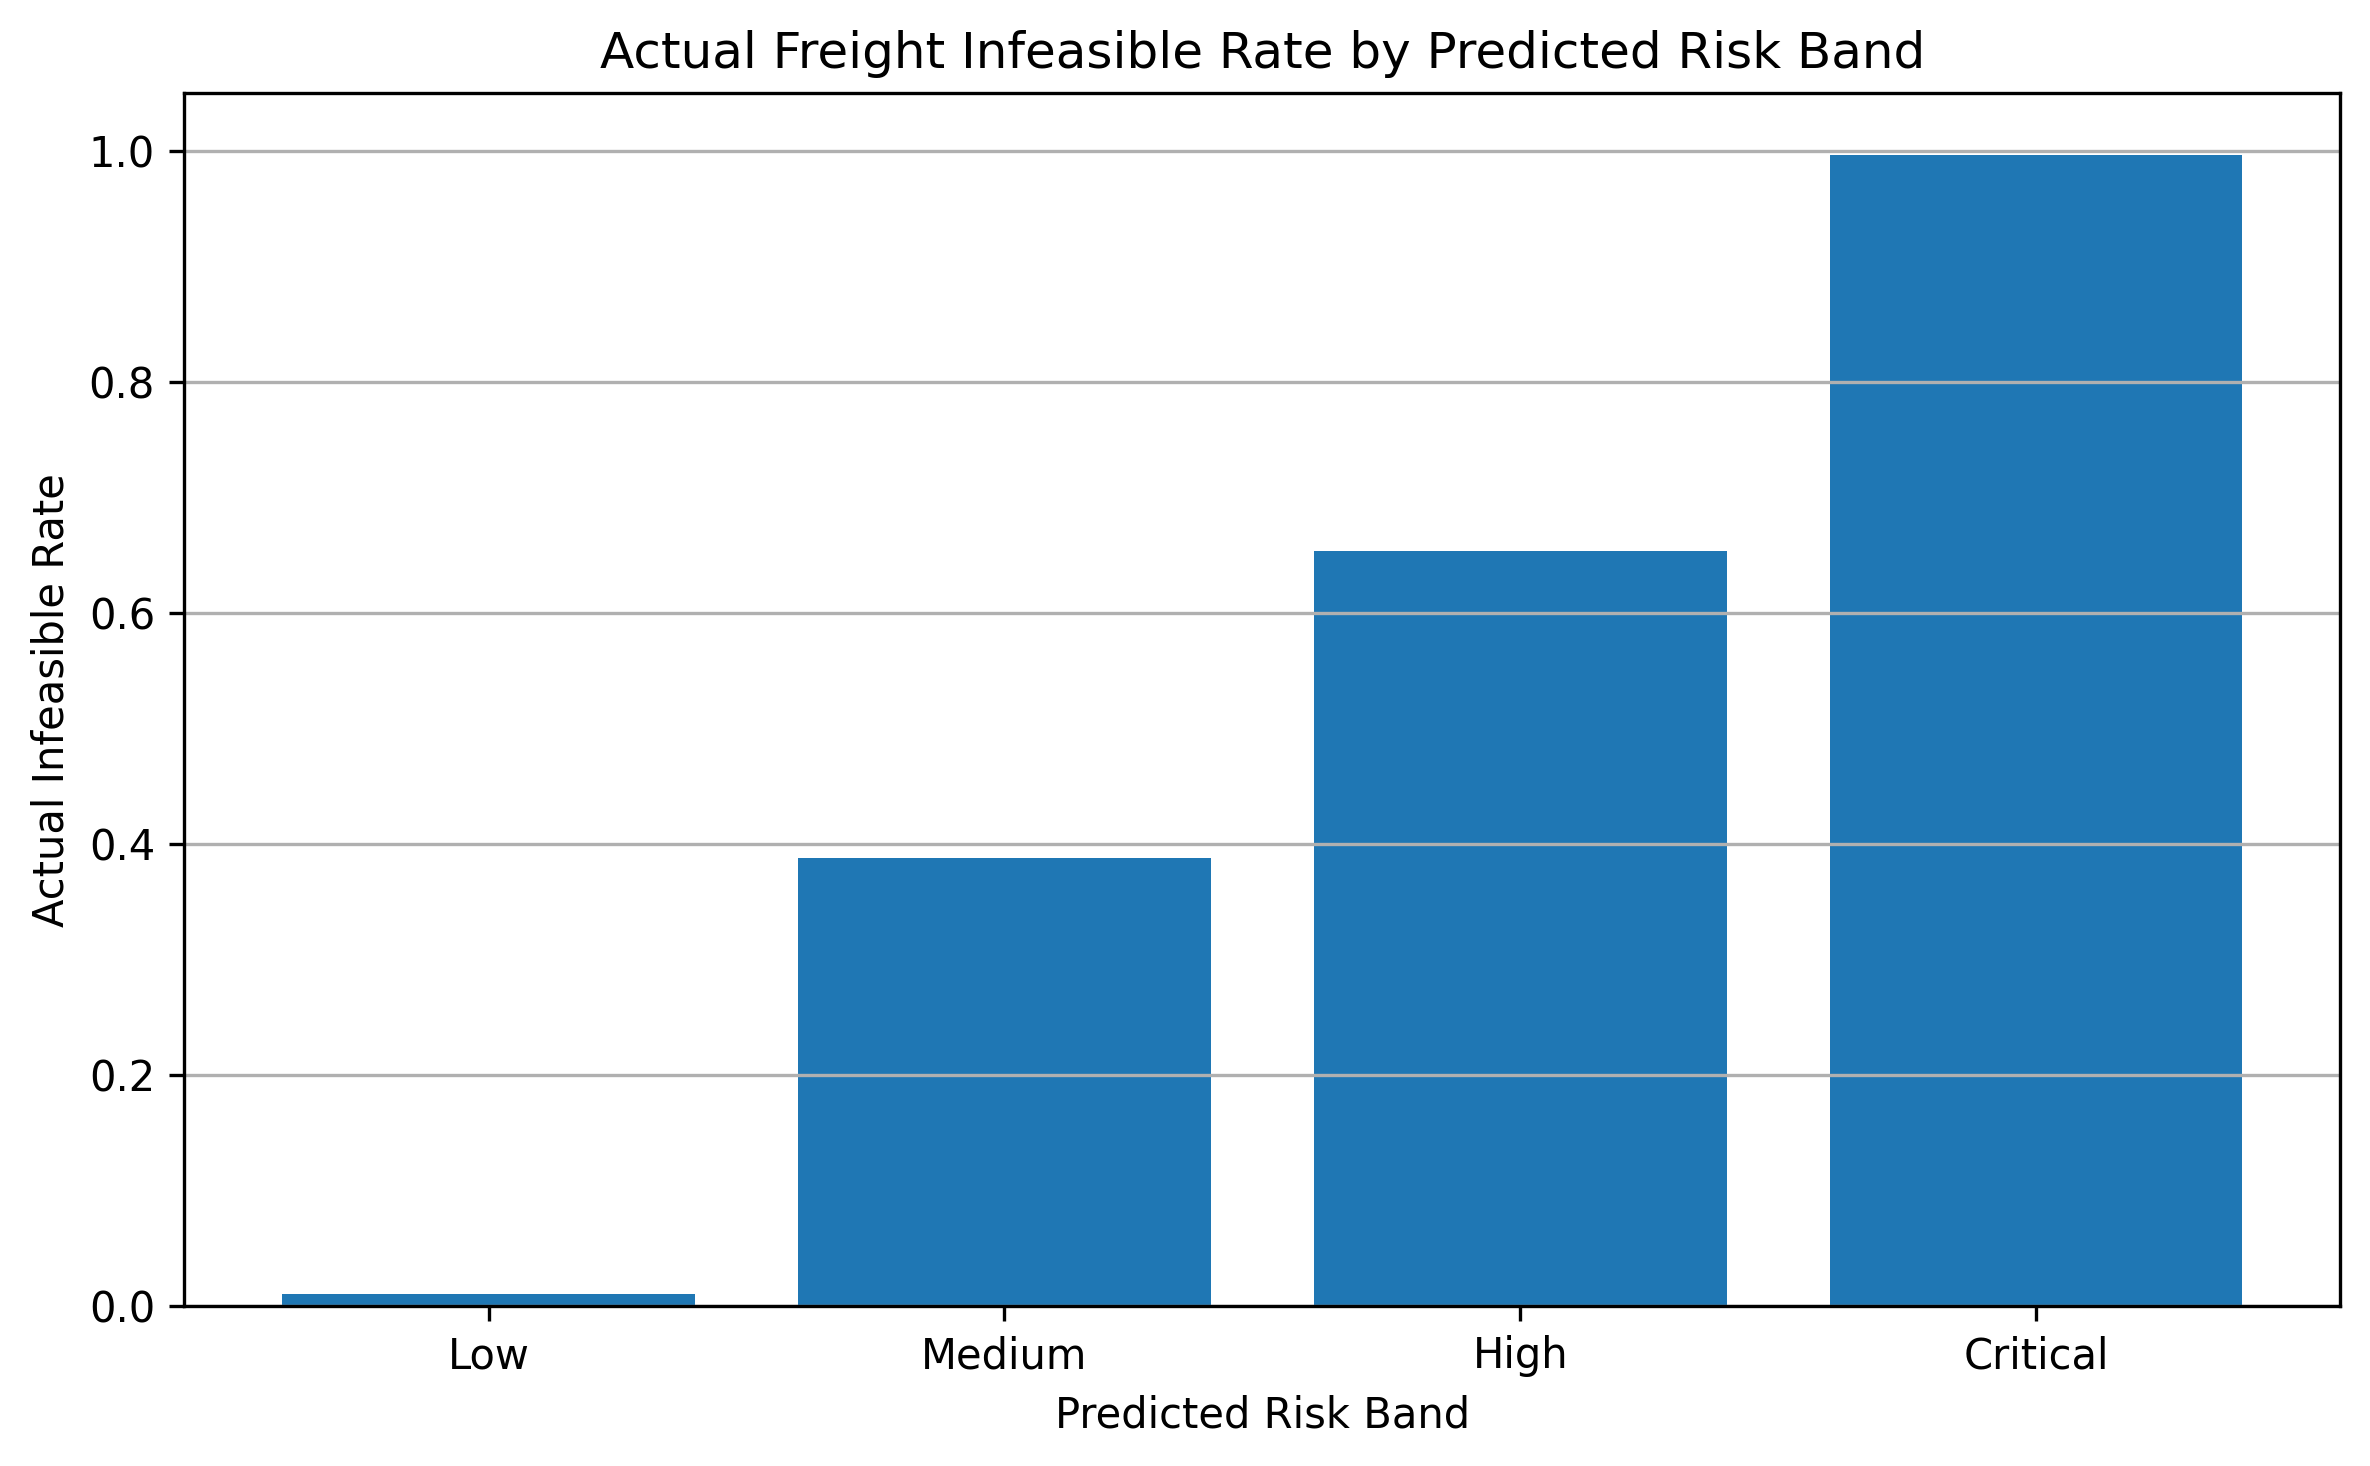

In [37]:
for fig_name in [
    "06_risk_band_order_count.png",
    "07_actual_infeasible_rate_by_risk_band.png"
]:
    fig_path = FIGURE_FOLDER / fig_name

    if fig_path.exists():
        display(Image(filename=str(fig_path)))
    else:
        print("Figure not found:", fig_path)

## 10. Risk Band Interpretation

The risk bands show clear separation:

- Low-risk orders have a very low actual infeasible rate.
- Medium and High orders are gray-area review groups.
- Critical orders are almost always infeasible.

This makes the model useful as a decision-support tool because it helps planners prioritize which orders should be reviewed first.

## 11. Sample Scored Orders

The scored test-set orders show how the final model output can appear in a frontend tool.

In [38]:
display(final_test_scored.head(20))

,origin_port,plant_code,plant_origin,unit_quantity,weight,log_unit_quantity,log_weight,weight_per_unit,log_weight_per_unit,ship_ahead_day_count,...,plant_over_capacity_flag,number_of_plants_that_support_product,plant_supported_product_count,product_is_single_plant_supported,has_vmi_rule,vmi_rule_satisfied,actual_freight_infeasible,predicted_risk_probability,predicted_freight_infeasible,risk_band
0,PORT04,PLANT03,PLANT03_PORT04,312,0.275142,5.746203,0.243057,0.000882,0.000881,3,...,1,1,781,1,0,1,0,0.400689,1,Medium
1,PORT04,PLANT03,PLANT03_PORT04,383,0.979024,5.950643,0.682604,0.002556,0.002553,3,...,1,1,781,1,0,1,0,0.001142,0,Low
2,PORT04,PLANT03,PLANT03_PORT04,447,4.293657,6.104793,1.666509,0.009605,0.009560,0,...,1,1,781,1,0,1,0,0.002445,0,Low
3,PORT04,PLANT03,PLANT03_PORT04,247,0.415441,5.513429,0.347441,0.001682,0.001681,5,...,1,4,781,0,1,0,0,0.005069,0,Low
4,PORT04,PLANT03,PLANT03_PORT04,563,24.343936,6.335054,3.232540,0.043240,0.042331,0,...,1,4,781,0,1,0,0,0.002048,0,Low
5,PORT04,PLANT03,PLANT03_PORT04,488,4.174275,6.192362,1.643699,0.008554,0.008517,3,...,1,1,781,1,0,1,0,0.001751,0,Low
6,PORT04,PLANT03,PLANT03_PORT04,787,7.400000,6.669498,2.128232,0.009403,0.009359,3,...,1,1,781,1,0,1,0,0.002564,0,Low
7,PORT04,PLANT03,PLANT03_PORT04,342,0.729661,5.837730,0.547925,0.002134,0.002131,0,...,1,4,781,0,0,1,0,0.000616,0,Low
8,PORT04,PLANT03,PLANT03_PORT04,450,11.380000,6.111467,2.516082,0.025289,0.024974,0,...,1,1,781,1,0,1,0,0.003018,0,Low
9,PORT04,PLANT03,PLANT03_PORT04,1827,120.719681,7.510978,4.801721,0.066075,0.063984,5,...,1,4,781,0,1,0,0,0.010184,0,Low


## 12. Final Capstone Conclusion

FreightRisk is a constraint-aware freight risk decision-support system.

The project combines EDA, target creation, feature engineering, multiple model families, threshold tuning, ensemble modeling, final model selection, and business-friendly risk bands.

Final modeling conclusion:

- Gradient Boosting is the best primary model.
- Stacking is the best ensemble model.
- Random Forest is the best high-recall backup model.
- Risk bands make the model output usable for operational prioritization.